In [16]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import random
import copy
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
learning_rate = 0.01
batch_size = 16
epochs = 30
train_size = 50000
val_size = 10000


torch.manual_seed(42)
random.seed(42)

In [4]:
transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

full_train_dataset = torchvision.datasets.MNIST(
    root ='./data',
    train = True,
    transform=transform,
    download = True
)
test_dataset = torchvision.datasets.MNIST(
    root ='./data',
    train = False,
    transform=transform,
    download = True
)
train_dataset, val_dataset = random_split(full_train_dataset,[train_size,val_size])
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [5]:
print("Train Data Size",len(train_dataset))
print("Validation Data Size",len(val_dataset))
print("Test Data Size",len(test_dataset))

Train Data Size 50000
Validation Data Size 10000
Test Data Size 10000


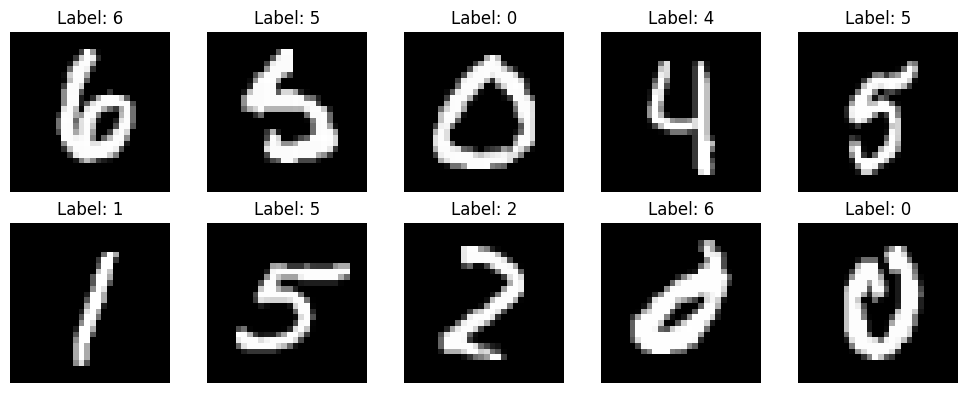

In [6]:

plt.figure(figsize=(10,4))
for i in range(10):
    idx = random.randint(0, len(train_dataset) - 1) 
    img, label = train_dataset[idx]
    img = img * 0.5 + 0.5
    img = img.squeeze().numpy()
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray') 
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
class MLPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),      
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,10)
        )
    def forward(self,x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits
mlp_model = MLPModel().to(device)
print(mlp_model)

MLPModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [8]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(

            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.flatten(x)   
        logits = self.classifier(x)
        return logits
cnn_model = CNNModel().to(device)

print(cnn_model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [9]:

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device, patience=5):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_loss = float('inf')
    counter = 0
    best_model = None
    
    for epoch in range(epochs):
        # ================= TRAIN =================
        model.train()
        running_loss = 0.0
        correct_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            correct_train += (outputs.argmax(1) == labels).sum().item()
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = (correct_train / len(train_loader.dataset)) * 100
        
        # ================= VALIDATION =================
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                val_outputs = model(inputs)
                val_loss = criterion(val_outputs, labels)
                
                val_running_loss += val_loss.item() * inputs.size(0)
                correct_val += (val_outputs.argmax(1) == labels).sum().item()
                
        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_acc = (correct_val / len(val_loader.dataset)) * 100
        
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)
        
        print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")
        
        if scheduler:
            scheduler.step()
            
        # ================= Early Stopping =================
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            counter = 0
            best_model = copy.deepcopy(model.state_dict()) 
        else:
            counter += 1
            
        if counter >= patience:
            print("Early Stopping triggered!")
            break
            
    if best_model:
        model.load_state_dict(best_model)
        
    return train_losses, val_losses, train_accuracies, val_accuracies

In [10]:
criterion = nn.CrossEntropyLoss()

mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.StepLR(mlp_optimizer,step_size=10,gamma=0.1)
mlp_train_losses, mlp_val_losses, mlp_train_accuracies, mlp_val_accuracies = train_model(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=mlp_optimizer,
    scheduler=scheduler, 
    epochs=epochs,
    device=device,
    patience=5
)


Epoch 1 | Train Loss: 0.9609 | Val Loss: 0.5183 | Train Acc: 69.18% | Val Acc: 84.90%
Epoch 2 | Train Loss: 0.8703 | Val Loss: 0.5513 | Train Acc: 72.92% | Val Acc: 86.26%
Epoch 3 | Train Loss: 0.9317 | Val Loss: 0.7936 | Train Acc: 71.73% | Val Acc: 78.59%
Epoch 4 | Train Loss: 0.9899 | Val Loss: 0.6482 | Train Acc: 70.31% | Val Acc: 79.31%
Epoch 5 | Train Loss: 0.9597 | Val Loss: 0.5095 | Train Acc: 70.71% | Val Acc: 87.53%
Epoch 6 | Train Loss: 1.0386 | Val Loss: 0.7127 | Train Acc: 68.49% | Val Acc: 82.98%
Epoch 7 | Train Loss: 1.1655 | Val Loss: 0.7257 | Train Acc: 62.38% | Val Acc: 83.98%
Epoch 8 | Train Loss: 1.0711 | Val Loss: 0.7942 | Train Acc: 66.51% | Val Acc: 78.13%
Epoch 9 | Train Loss: 1.0834 | Val Loss: 1.1852 | Train Acc: 66.14% | Val Acc: 61.70%
Epoch 10 | Train Loss: 1.0801 | Val Loss: 0.6941 | Train Acc: 67.10% | Val Acc: 84.11%
Early Stopping triggered!


In [11]:
criterion = nn.CrossEntropyLoss()

mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(mlp_optimizer,step_size=10,gamma=0.1)
mlp_train_losses2, mlp_val_losses2, mlp_train_accuracies2, mlp_val_accuracies2 = train_model(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=mlp_optimizer,
    scheduler=scheduler, 
    epochs=epochs,
    device=device,
    patience=5
)


Epoch 1 | Train Loss: 0.7620 | Val Loss: 0.4432 | Train Acc: 76.56% | Val Acc: 88.78%
Epoch 2 | Train Loss: 0.7070 | Val Loss: 0.4228 | Train Acc: 78.55% | Val Acc: 89.64%
Epoch 3 | Train Loss: 0.6854 | Val Loss: 0.4131 | Train Acc: 79.04% | Val Acc: 89.57%
Epoch 4 | Train Loss: 0.6727 | Val Loss: 0.4046 | Train Acc: 79.25% | Val Acc: 90.13%
Epoch 5 | Train Loss: 0.6482 | Val Loss: 0.3867 | Train Acc: 80.17% | Val Acc: 89.76%
Epoch 6 | Train Loss: 0.6382 | Val Loss: 0.3851 | Train Acc: 80.65% | Val Acc: 89.86%
Epoch 7 | Train Loss: 0.6291 | Val Loss: 0.3686 | Train Acc: 80.70% | Val Acc: 89.85%
Epoch 8 | Train Loss: 0.6141 | Val Loss: 0.3698 | Train Acc: 81.19% | Val Acc: 89.89%
Epoch 9 | Train Loss: 0.6269 | Val Loss: 0.3706 | Train Acc: 81.20% | Val Acc: 90.16%
Epoch 10 | Train Loss: 0.6102 | Val Loss: 0.3607 | Train Acc: 81.35% | Val Acc: 90.17%
Epoch 11 | Train Loss: 0.5992 | Val Loss: 0.3566 | Train Acc: 81.82% | Val Acc: 90.51%
Epoch 12 | Train Loss: 0.5915 | Val Loss: 0.3549 | T

In [12]:

cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=learning_rate)

cnn_train_losses, cnn_val_losses, cnn_train_accuracies, cnn_val_accuracies = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=cnn_optimizer,
    scheduler=None, 
    epochs=epochs,
    device=device,
    patience=5
)


Epoch 1 | Train Loss: 0.4288 | Val Loss: 0.1948 | Train Acc: 87.22% | Val Acc: 94.60%
Epoch 2 | Train Loss: 0.3321 | Val Loss: 0.1624 | Train Acc: 90.78% | Val Acc: 95.90%
Epoch 3 | Train Loss: 0.3039 | Val Loss: 0.1982 | Train Acc: 91.66% | Val Acc: 94.86%
Epoch 4 | Train Loss: 0.3013 | Val Loss: 0.2097 | Train Acc: 91.93% | Val Acc: 94.38%
Epoch 5 | Train Loss: 0.2912 | Val Loss: 0.1799 | Train Acc: 92.21% | Val Acc: 96.00%
Epoch 6 | Train Loss: 0.2907 | Val Loss: 0.2093 | Train Acc: 92.18% | Val Acc: 94.75%
Epoch 7 | Train Loss: 0.2873 | Val Loss: 0.2045 | Train Acc: 92.29% | Val Acc: 95.32%
Early Stopping triggered!


In [13]:
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=learning_rate)

cnn_train_losses2, cnn_val_losses2, cnn_train_accuracies2, cnn_val_accuracies2 = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=cnn_optimizer,
    scheduler=None, 
    epochs=epochs,
    device=device,
    patience=10
)


Epoch 1 | Train Loss: 0.3119 | Val Loss: 0.1904 | Train Acc: 91.38% | Val Acc: 94.92%
Epoch 2 | Train Loss: 0.3025 | Val Loss: 0.1852 | Train Acc: 91.54% | Val Acc: 94.99%
Epoch 3 | Train Loss: 0.2969 | Val Loss: 0.1703 | Train Acc: 92.04% | Val Acc: 95.97%
Epoch 4 | Train Loss: 0.2917 | Val Loss: 0.1996 | Train Acc: 92.24% | Val Acc: 95.06%
Epoch 5 | Train Loss: 0.2853 | Val Loss: 0.1811 | Train Acc: 92.41% | Val Acc: 95.87%
Epoch 6 | Train Loss: 0.2800 | Val Loss: 0.1895 | Train Acc: 92.72% | Val Acc: 95.50%
Epoch 7 | Train Loss: 0.2984 | Val Loss: 0.1889 | Train Acc: 92.14% | Val Acc: 95.35%
Epoch 8 | Train Loss: 0.2833 | Val Loss: 0.2074 | Train Acc: 92.47% | Val Acc: 95.41%
Epoch 9 | Train Loss: 0.2813 | Val Loss: 0.1796 | Train Acc: 92.79% | Val Acc: 95.92%
Epoch 10 | Train Loss: 0.2895 | Val Loss: 0.1969 | Train Acc: 92.32% | Val Acc: 95.57%
Epoch 11 | Train Loss: 0.2822 | Val Loss: 0.1909 | Train Acc: 92.49% | Val Acc: 95.85%
Epoch 12 | Train Loss: 0.2900 | Val Loss: 0.1882 | T

In [14]:
def test_model(model, test_loader, criterion, device):
    model.eval() 
    test_loss = 0.0
    correct_test = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            correct_test += (outputs.argmax(1) == labels).sum().item()
            
    avg_loss = test_loss / len(test_loader.dataset)
    accuracy = (correct_test / len(test_loader.dataset)) * 100
    
    return avg_loss, accuracy


print("MLP Model Test Results\n")
mlp_test_loss, mlp_test_acc = test_model(mlp_model, test_loader, criterion, device)
print(f"Test Loss: {mlp_test_loss:.4f} | Test Accuracy: {mlp_test_acc:.2f}%\n")

print("CNN Model Test Results\n")
cnn_test_loss, cnn_test_acc = test_model(cnn_model, test_loader, criterion, device)
print(f"Test Loss: {cnn_test_loss:.4f} | Test Accuracy: {cnn_test_acc:.2f}%")

MLP Model Test Results

Test Loss: 0.3353 | Test Accuracy: 91.08%

CNN Model Test Results

Test Loss: 0.1300 | Test Accuracy: 96.57%


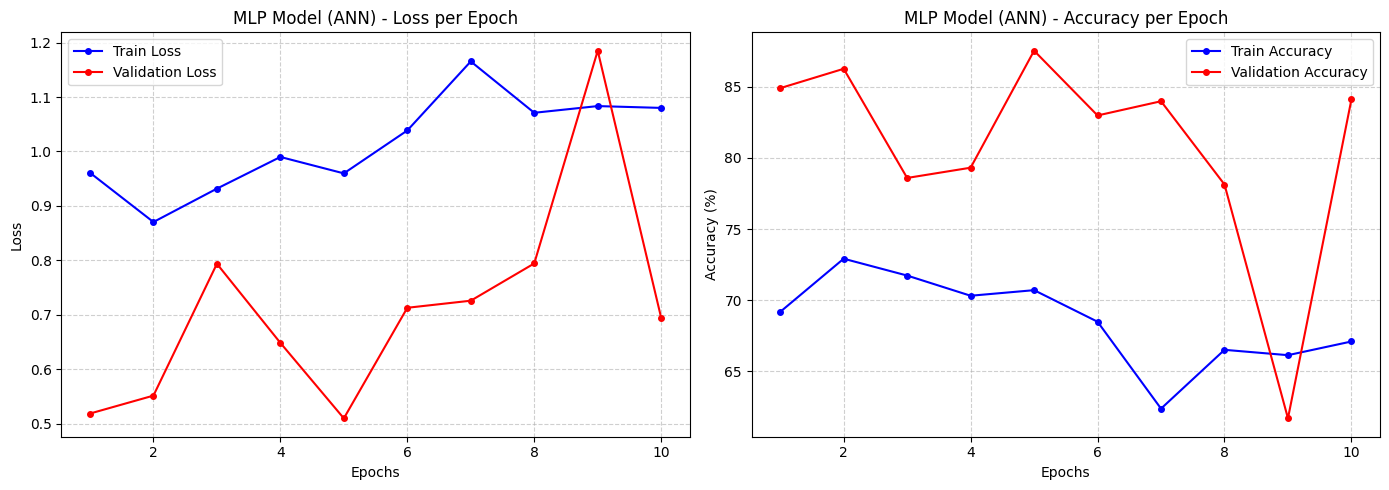

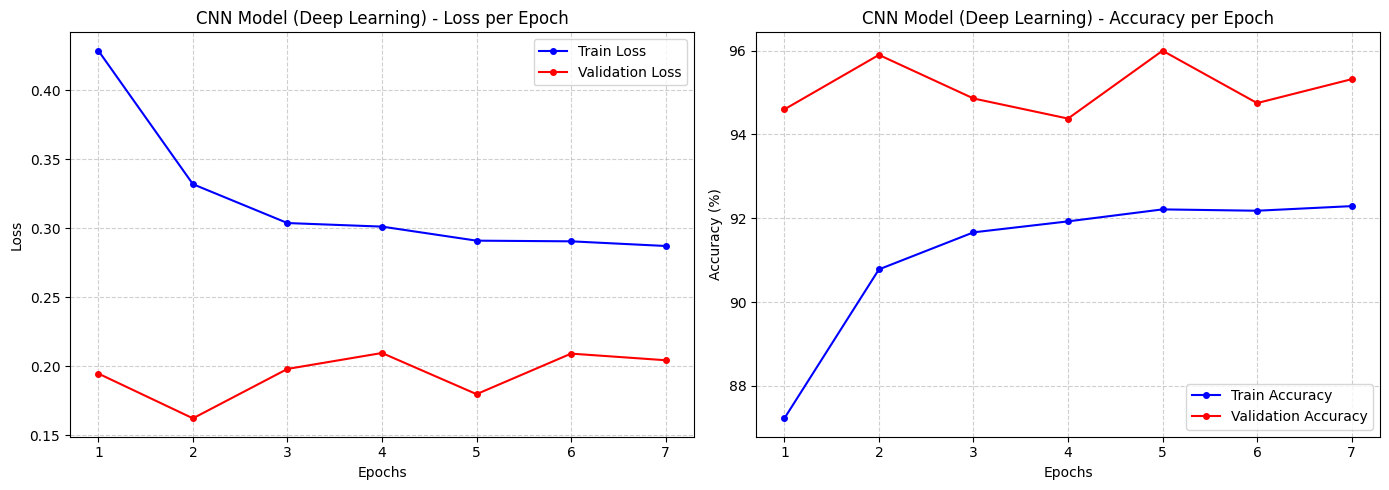

In [15]:

import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, train_accs, val_accs, model_name):
    epochs_range = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o', markersize=4)
    plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', marker='o', markersize=4)
    plt.title(f'{model_name} - Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accs, label='Train Accuracy', color='blue', marker='o', markersize=4)
    plt.plot(epochs_range, val_accs, label='Validation Accuracy', color='red', marker='o', markersize=4)
    plt.title(f'{model_name} - Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_metrics(mlp_train_losses, mlp_val_losses, mlp_train_accuracies, mlp_val_accuracies, "MLP Model (ANN)")

plot_metrics(cnn_train_losses, cnn_val_losses, cnn_train_accuracies, cnn_val_accuracies, "CNN Model (Deep Learning)")

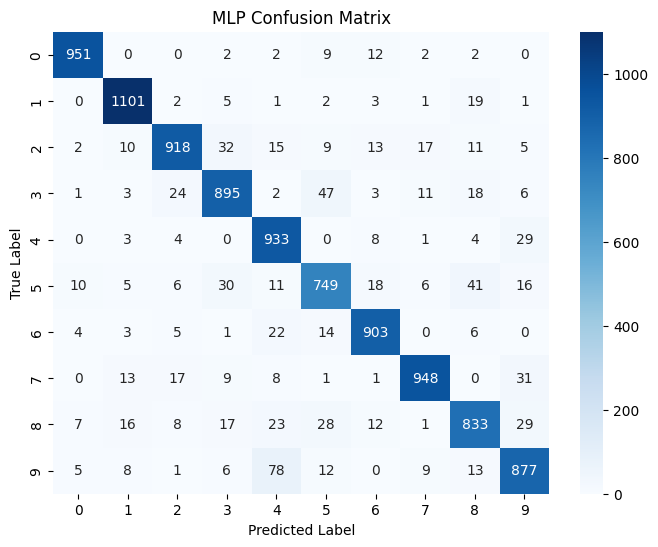

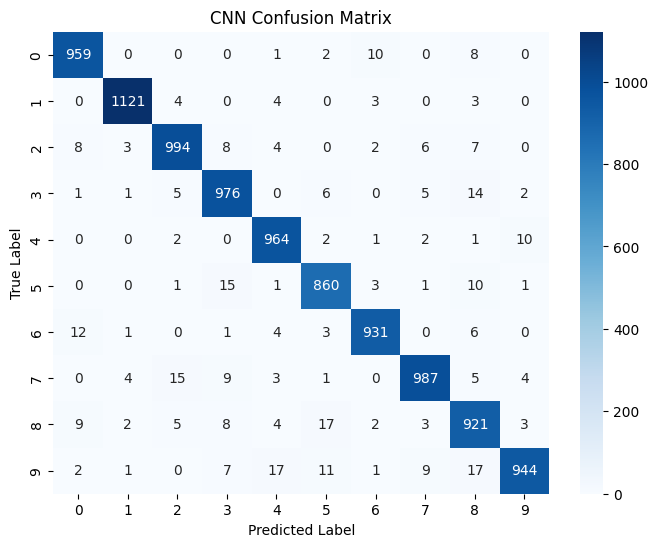

In [17]:
def plot_confusion_matrix(model, test_loader, device, title):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

plot_confusion_matrix(mlp_model, test_loader, device, "MLP Confusion Matrix")
plot_confusion_matrix(cnn_model, test_loader, device, "CNN Confusion Matrix")